limpieza de datos

In [2]:
import pandas as pd
import os

In [3]:
# Define tus rutas de archivos
csv_path = r'C:\Users\drive\OneDrive\Escritorio\data\datos_raw\aptos_2019\train.csv'
images_folder = r'C:\Users\drive\OneDrive\Escritorio\data\datos_raw\aptos_2019\train'

# Paso 1: Carga el archivo CSV original
try:
    df_original = pd.read_csv(csv_path)
except FileNotFoundError:
    print("Error: No se encontró el archivo CSV original. Revisa la ruta.")
    exit()

# Paso 2: Obtén la lista de IDs de las imágenes que realmente tienes
try:
    files_in_folder = os.listdir(images_folder)
    # Extrae solo los nombres de los archivos (sin extensión)
    image_ids_in_folder = {os.path.splitext(f)[0] for f in files_in_folder}
except FileNotFoundError:
    print("Error: No se encontró la carpeta de imágenes. Revisa la ruta.")
    exit()

# Paso 3: Filtra el DataFrame original
# Crea un nuevo DataFrame que solo incluya los IDs que existen en la carpeta
df_clean = df_original[df_original['image'].isin(image_ids_in_folder)]

# Paso 4: Guarda el DataFrame limpio en un nuevo archivo CSV
clean_csv_path = 'aptos_train_cleaned.csv'
df_clean.to_csv(clean_csv_path, index=False)

print(f"Limpieza completada. {len(df_clean)} de {len(df_original)} imágenes son válidas.")
print(f"El dataset limpio ha sido guardado en: {clean_csv_path}")

Limpieza completada. 2930 de 3662 imágenes son válidas.
El dataset limpio ha sido guardado en: aptos_train_cleaned.csv


grafico de cantidad de data en cada nivel

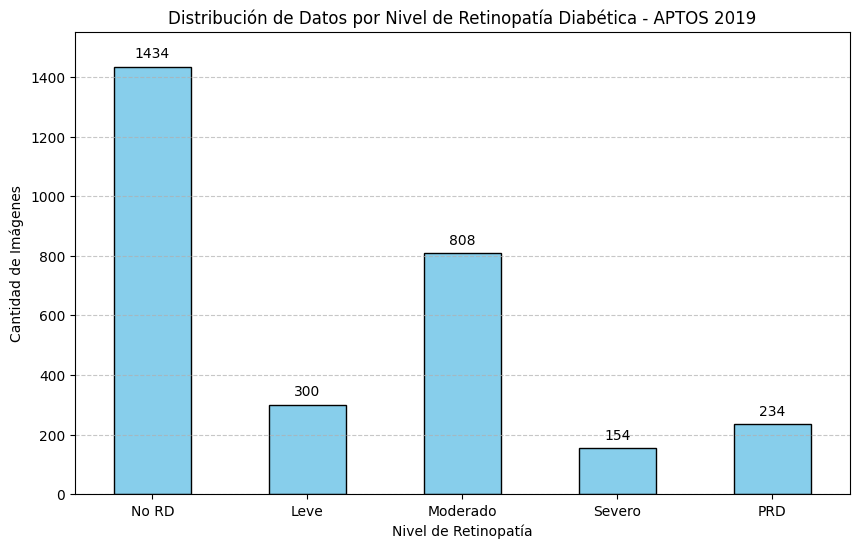

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# La ruta indica el dataset APTOS 2019
file_path = r'C:\Users\drive\OneDrive\Escritorio\data\datos_raw\aptos_2019\train.csv'

try:
    # Carga el dataset
    df = pd.read_csv(file_path)

    # Cuenta las imágenes para cada nivel de retinopatía y ordena
    level_counts = df['level'].value_counts().sort_index()

    # --- AJUSTE CLAVE: RENOMBRAR LOS NIVELES ---
    level_map = {
        0: 'No RD',
        1: 'Leve',
        2: 'Moderado',
        3: 'Severo',
        4: 'PRD'
    }
    level_counts = level_counts.rename(index=level_map)
    # ---------------------------------------------

    # Crea la figura y los ejes para el gráfico
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Genera el gráfico de barras
    bars = level_counts.plot(kind='bar', color='skyblue', edgecolor='black', ax=ax)
    
    # --- Añadir las etiquetas de datos (números) sobre las barras ---
    # AJUSTE 1: Reducir el desplazamiento a un valor pequeño (e.g., 20)
    # apropiado para la escala de 0 a 1500.
    VERTICAL_OFFSET = 20  

    for bar in bars.patches:
        height = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2.0
        
        ax.text(
            x_pos, 
            height + VERTICAL_OFFSET,  # Usa el desplazamiento pequeño
            f'{int(height)}',  
            ha='center', 
            va='bottom',
        )
    # ------------------------------------------------------------------

    # Configuración del gráfico
    # El título debe reflejar el dataset correcto
    ax.set_title('Distribución de Datos por Nivel de Retinopatía Diabética - APTOS 2019')
    ax.set_xlabel('Nivel de Retinopatía')
    ax.set_ylabel('Cantidad de Imágenes')
    
    plt.xticks(rotation=0) 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # AJUSTE 2: Ajustar el límite superior del eje Y.
    y_max = level_counts.max() # El máximo es 1434
    # Establecer el límite ligeramente por encima del número más alto (ej. 1500 + 50)
    ax.set_ylim(top=1550) 
    
    # Guarda y muestra el gráfico
    plt.savefig('distribucion_niveles_aptos_reajustado.png')
    plt.show()
    
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta '{file_path}'. Por favor, verifica la ruta de acceso.")

Procesando archivos CSV...
  > Datos de 'APTOS 2019' cargados exitosamente.
  > Datos de 'EyePACS' cargados exitosamente.
  > Datos de 'IDRiD' cargados exitosamente.
  > Datos de 'Messidor' cargados exitosamente.

Tabla de datos consolidada:
          APTOS 2019  EyePACS  IDRiD  Messidor
level                                         
No RD           1434    25810    134       468
Leve             300     2443     20       202
Moderado         808     5292    136       284
Severo           154      873     74        71
PRD              234      708     49        21

✅ Gráfico comparativo guardado exitosamente en: C:\Users\drive\OneDrive\Escritorio\graficos_distribucion\distribucion_comparativa_datasets.png


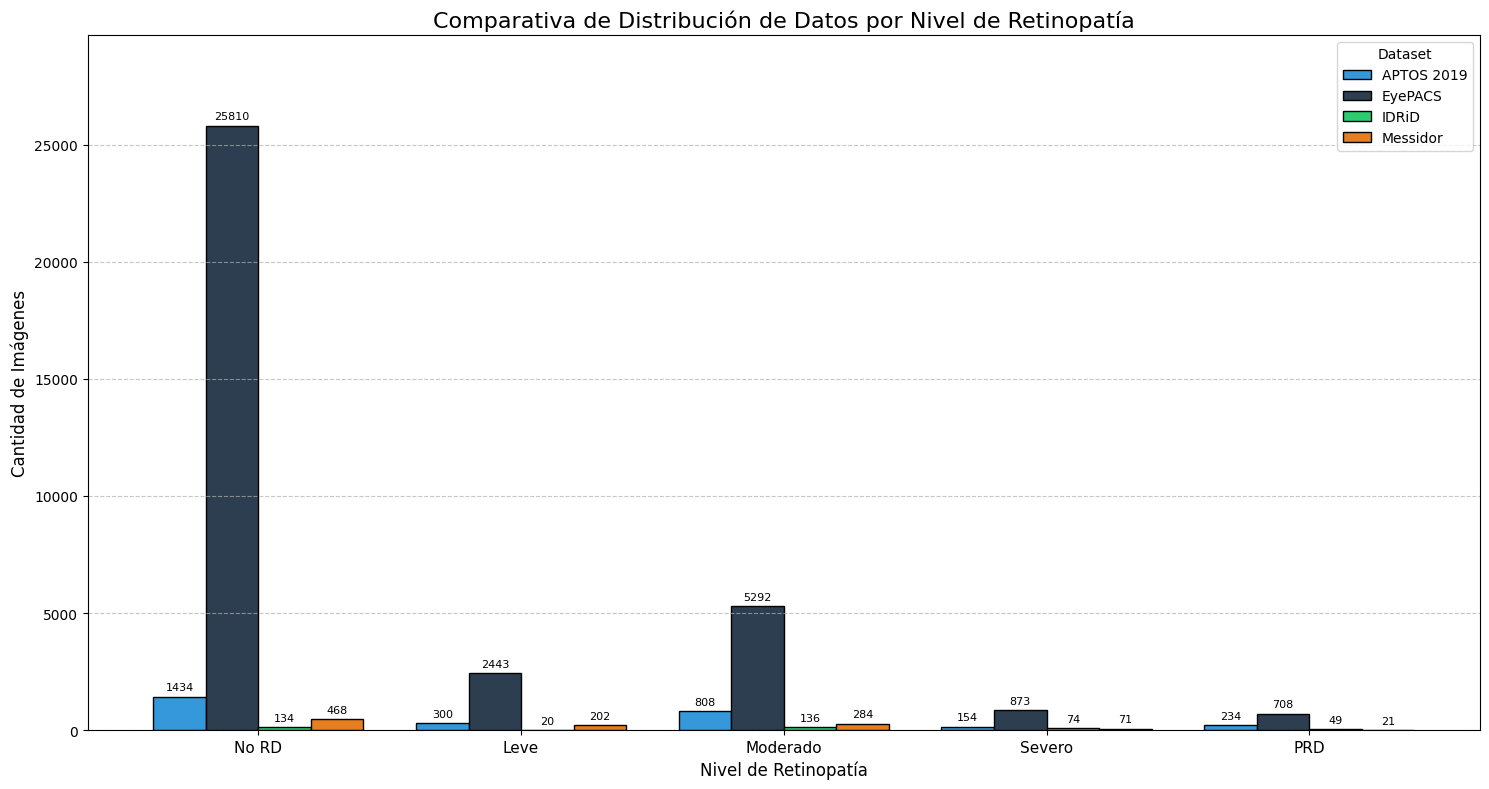

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# --- CONFIGURACIÓN PRINCIPAL (Igual que antes) ---

# 1. Directorio donde se guardará el gráfico final.
OUTPUT_DIRECTORY = r'C:\Users\drive\OneDrive\Escritorio\graficos_distribucion'
if not os.path.exists(OUTPUT_DIRECTORY):
    os.makedirs(OUTPUT_DIRECTORY)

# 2. Ruta base donde se encuentran tus carpetas de datos.
BASE_DATA_PATH = r'C:\Users\drive\OneDrive\Escritorio\data\datos_raw'

# 3. Diccionario con la información de cada dataset.
#    ¡IMPORTANTE! Verifica que las rutas y nombres de archivo sean correctos.
DATASETS = {
    'APTOS 2019': os.path.join(BASE_DATA_PATH, 'aptos_2019', 'train.csv'),
    'EyePACS': os.path.join(BASE_DATA_PATH, 'eyePACS', 'train.csv'),
    'IDRiD': os.path.join(BASE_DATA_PATH, 'idrid', 'train.csv'),
    'Messidor': os.path.join(BASE_DATA_PATH, 'messidor', 'train.csv')
}

# 4. Mapeo de niveles numéricos a etiquetas de texto.
LEVEL_MAP = {
    0: 'No RD',
    1: 'Leve',
    2: 'Moderado',
    3: 'Severo',
    4: 'PRD'
}

# --- PROCESAMIENTO Y AGREGACIÓN DE DATOS ---

# Diccionario para almacenar las cuentas de cada dataset
all_counts = {}

print("Procesando archivos CSV...")
for dataset_name, file_path in DATASETS.items():
    try:
        df = pd.read_csv(file_path)
        
        # Asumiendo que la columna se llama 'level' o 'diagnosis'
        column_name = 'level' if 'level' in df.columns else 'diagnosis'
        if column_name not in df.columns:
            print(f"Advertencia: No se encontró la columna 'level' o 'diagnosis' en '{dataset_name}'. Saltando este archivo.")
            continue
            
        # Contar los valores y guardarlos en el diccionario
        all_counts[dataset_name] = df[column_name].value_counts()
        print(f"  > Datos de '{dataset_name}' cargados exitosamente.")

    except FileNotFoundError:
        print(f"❌ Error: No se encontró el archivo para '{dataset_name}' en la ruta '{file_path}'.")
    except Exception as e:
        print(f"❌ Ocurrió un error inesperado al procesar '{dataset_name}': {e}")

# --- CREACIÓN DEL DATAFRAME COMBINADO ---

# Convierte el diccionario de cuentas en un único DataFrame
# Cada dataset será una columna y cada nivel de retinopatía una fila
combined_df = pd.DataFrame(all_counts)

# Rellena los valores faltantes (si un dataset no tiene un nivel) con 0
combined_df = combined_df.fillna(0).astype(int)

# Renombra el índice del DataFrame usando el mapeo de niveles
combined_df = combined_df.rename(index=LEVEL_MAP)

# Asegura el orden correcto de las categorías (No RD, Leve, Moderado, etc.)
desired_order = [LEVEL_MAP[i] for i in range(5) if LEVEL_MAP[i] in combined_df.index]
combined_df = combined_df.reindex(desired_order)

print("\nTabla de datos consolidada:")
print(combined_df)


# --- GENERACIÓN DEL GRÁFICO AGRUPADO ---

# Define una paleta de colores para el gráfico
colors = ['#3498db', '#2c3e50', '#2ecc71', '#e67e22']

# Crea la figura y los ejes con un tamaño adecuado
fig, ax = plt.subplots(figsize=(15, 8))

# Genera el gráfico de barras agrupado
combined_df.plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.8)

# Añade etiquetas con el número sobre cada barra
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

# --- CONFIGURACIÓN Y ESTILO DEL GRÁFICO ---
ax.set_title('Comparativa de Distribución de Datos por Nivel de Retinopatía', fontsize=16)
ax.set_xlabel('Nivel de Retinopatía', fontsize=12)
ax.set_ylabel('Cantidad de Imágenes', fontsize=12)
ax.legend(title='Dataset', fontsize=10)
plt.xticks(rotation=0, ha='center', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajusta el límite del eje Y para dar espacio a las etiquetas
y_max = combined_df.max().max()
ax.set_ylim(top=y_max * 1.15) # Añade un 15% de margen superior

# Ajusta el diseño para que no se corte nada
plt.tight_layout()

# --- GUARDADO DEL GRÁFICO ---
save_path = os.path.join(OUTPUT_DIRECTORY, 'distribucion_comparativa_datasets.png')
plt.savefig(save_path)

print(f"\n✅ Gráfico comparativo guardado exitosamente en: {save_path}")

# Muestra el gráfico en pantalla
plt.show()